# `CPPStructurePlot.map_structure`

Paint per-residue **CPP / CPP-SHAP feature impact** onto a 3D protein structure. Each feature in a `df_feat` is mapped to the residues it spans and its signed impact is aggregated per residue with the **same normalized-sum** as `CPPPlot.profile`, then painted onto the structure cartoon. The method returns a `StructureView` with a uniform `show()` / `write_html()` / `savefig()` surface over an interactive **py3Dmol** backend and a static **matplotlib** fallback (used here so the figures render in the docs).

This is a `pro` feature (needs `biopython`; `py3Dmol` for the interactive backend).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
import aaanalysis.utils as ut

aa.options["verbose"] = False

## A tiny structure and `df_feat`

Normally you pass a real `.pdb` / `.cif` path (`pdb=...`) or a UniProt accession (`uniprot=...`, auto-fetched from AlphaFold DB). For a self-contained example we write a small synthetic structure (one Cα per residue; the B-factor column doubles as pLDDT) and a `df_feat` with two known features — a whole-TMD segment and a whole-JMD-N segment.

In [2]:
import tempfile, os
tmp = tempfile.mkdtemp()
pdb = os.path.join(tmp, 'demo.pdb')
lines = []
for i in range(40):
    x, y, z = i*1.5, np.sin(i*0.5)*5, np.cos(i*0.5)*5
    b = 40 + (i % 60)   # pLDDT-like 40..99 in the B-factor column
    lines.append(f"ATOM  {i+1:5d}  CA  ALA A{i+1:4d}    {x:8.3f}{y:8.3f}{z:8.3f}  1.00{b:6.2f}           C")
lines.append('END')
open(pdb, 'w').write('\n'.join(lines) + '\n')

df_feat = pd.DataFrame({
    ut.COL_FEATURE: ['TMD-Segment(1,1)-LDKE', 'JMD_N-Segment(1,1)-CHAM'],
    'category': ['Polarity', 'Energy'],
    'feat_impact': [0.8, -0.4],
})
aa.display_df(df_feat, n_rows=10, show_shape=True)

DataFrame shape: (2, 3)


,feature,category,feat_impact
1,"TMD-Segment(1,1)-LDKE",Polarity,0.800000
2,"JMD_N-Segment(1,1)-CHAM",Energy,-0.400000


## Construct the plotter

`jmd_n_len` / `jmd_c_len` are the juxta-membrane lengths used when the features were generated (stored and reused by `map_structure`, mirroring `CPPPlot`). `df_scales` is accepted for parity with `CPPPlot` but is not needed for structure mapping.

In [3]:
csp = aa.CPPStructurePlot(jmd_n_len=10, jmd_c_len=10, df_scales=None, verbose=False)

## Impact mode with fade-context

`mode="impact"` paints the white→red / white→blue ramp (red raises, blue lowers the prediction). `focus="fade"` ghosts residues outside the feature window; `size_by_impact` scales the per-residue marker / stick by `|impact|`. `col_imp` selects the signed impact column, `tmd_len` the TMD length, and `start` the absolute residue number of the first JMD-N residue (here the features cover residues 1..20).

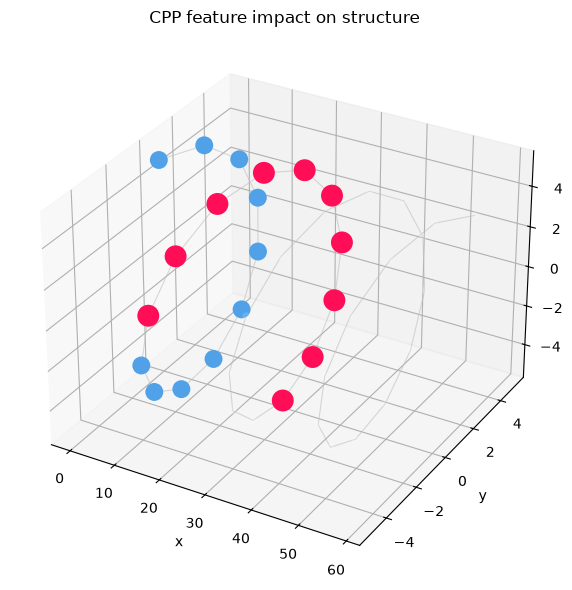

In [4]:
view = csp.map_structure(df_feat=df_feat, pdb=pdb, col_imp='feat_impact',
                         tmd_len=10, start=1, mode='impact', focus='fade',
                         size_by_impact=True, backend='mpl')
plt.tight_layout()
plt.show()

The per-residue impact is the normalized sum: the TMD impact `0.8` spread over its 10 residues gives `0.08` each; the JMD-N impact `-0.4` gives `-0.04` each.

In [5]:
df_imp = pd.DataFrame({'residue': list(view.dict_impact),
                       'impact': [round(v, 3) for v in view.dict_impact.values()]})
aa.display_df(df_imp, n_rows=10, show_shape=True)

DataFrame shape: (30, 2)


,residue,impact
1,1,-0.040000
2,2,-0.040000
3,3,-0.040000
4,4,-0.040000
5,5,-0.040000
6,6,-0.040000
7,7,-0.040000
8,8,-0.040000
9,9,-0.040000
10,10,-0.040000


## Zoom-to-window, an explicit `focus_region`, and chain / sequence selection

`focus="zoom"` points the camera at the window; `focus_region=(start, stop)` (or a list of ranges) overrides the auto window. `chain` picks a chain by id; `sequence` enables best-matching-chain selection and a sanity check that `start` lines up with the structure.

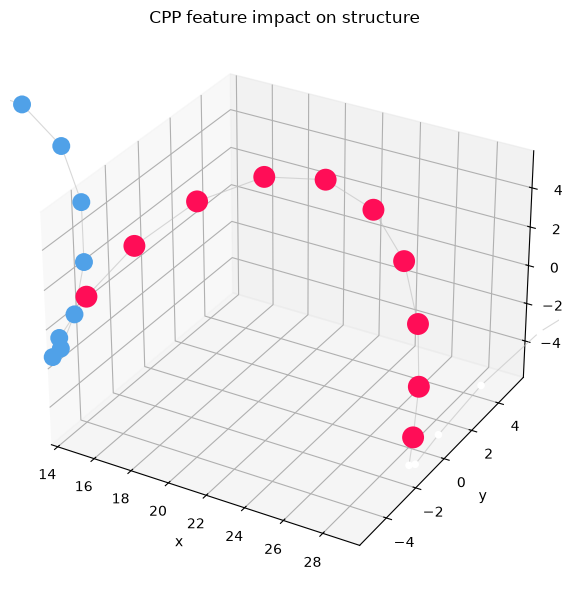

In [6]:
view_zoom = csp.map_structure(df_feat=df_feat, pdb=pdb, tmd_len=10, start=1,
                              mode='impact', focus='zoom', focus_region=(11, 20),
                              chain='A', sequence='A'*40, backend='mpl')
plt.tight_layout()
plt.show()

## pLDDT confidence mode

`mode="plddt"` ignores the impact and paints the AlphaFold confidence palette (blue = high, orange = low) read from the structure's B-factor column.

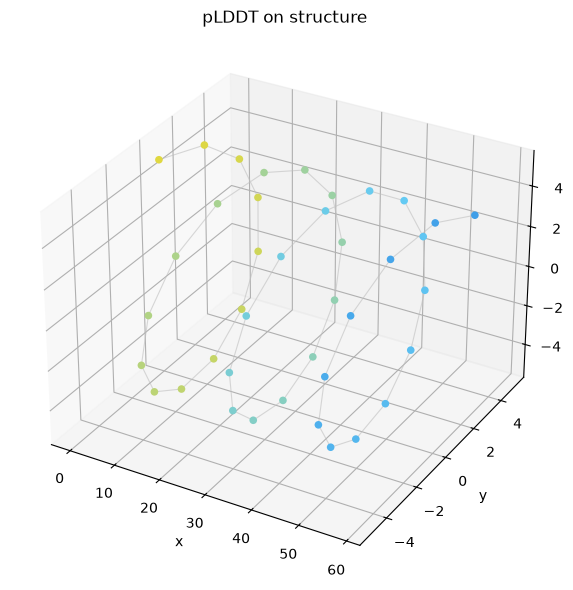

In [7]:
view_plddt = csp.map_structure(df_feat=df_feat, pdb=pdb, tmd_len=10, start=1,
                               mode='plddt', focus='whole', backend='mpl')
plt.tight_layout()
plt.show()

## Interactive backend, HTML export, and AlphaFold auto-fetch

With `backend=None` (the default) py3Dmol is used when available, otherwise matplotlib. The interactive view exports a self-contained page with `write_html(path)`; the static backend writes a PNG with `savefig(path)`. To fetch the structure straight from AlphaFold DB, pass `uniprot=` instead of `pdb=`:

```python
view = csp.map_structure(df_feat=df_feat, uniprot='Q9NQ76', tmd_len=10, start=312)
view.write_html('adamts7.html')   # interactive, shareable
```

In [8]:
html_path = os.path.join(tmp, 'view.html')
view_auto = csp.map_structure(df_feat=df_feat, pdb=pdb, tmd_len=10, backend=None)
view_auto.write_html(html_path)
print('backend:', view_auto.backend, '| wrote', os.path.basename(html_path),
      '(', os.path.getsize(html_path), 'bytes )')

backend: py3dmol | wrote view.html ( 9954 bytes )
